[[1.        0.9319369]
 [0.9319369 1.       ]]


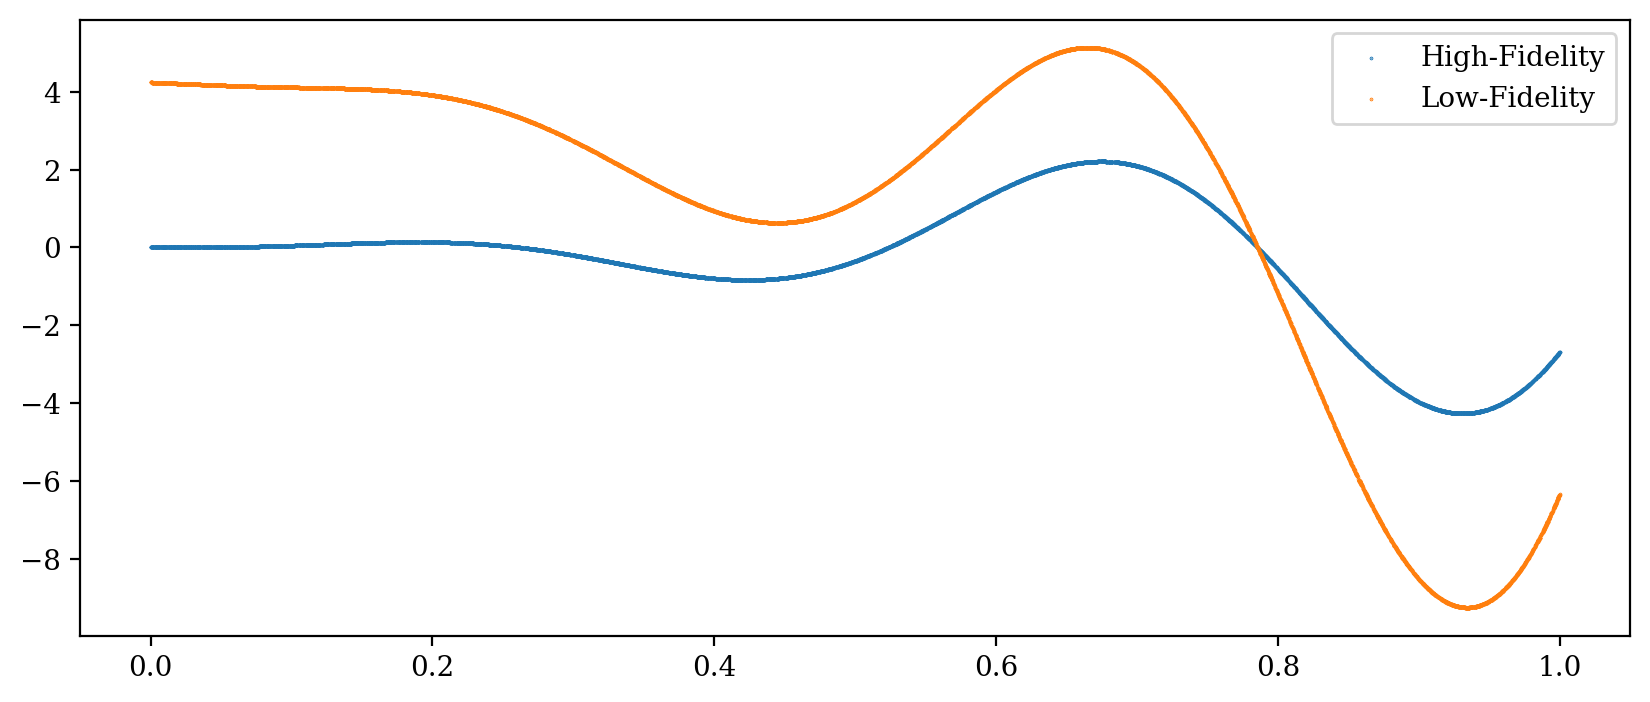

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
from tqdm import tqdm 
import math 

# Plot parameters 
plt.rcParams.update({
    "font.family": "serif",
    'text.latex.preamble': r'\\usepackage{amsmath}',
    'mathtext.fontset': 'cm',
})

# LINEAR-B 
funcs = [
    lambda x: ((5*x**2) * np.sin(12*x)), 
    lambda x: (2*(5*x**2) * np.sin(12*x)+(x**3-0.5*np.sin(3*x-0.5))+4*np.cos(2*x))]

# Setting the minimum condition number
rcond = 1e-15

# Computing moments 
n_pilot = 10000 
z_pilot = np.random.uniform(0,1,n_pilot)

# Creating polynomial features and standard scaling 
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
scaler, features = StandardScaler(), PolynomialFeatures(degree=8)
X_pilot = scaler.fit_transform(features.fit_transform(z_pilot.reshape(-1,1)))
d = X_pilot.shape[1]

# Obtaining pilot samples for y1 and y2
y1_pilot = funcs[0](z_pilot)
y2_pilot = funcs[1](z_pilot)

# Computing means 
y1_mean = np.mean(y1_pilot)
y2_mean = np.mean(y2_pilot)

# Creating the variable w = x*y(x)
xy1_pilot = X_pilot.T * (y1_pilot - y1_mean).reshape(1,-1)
xy2_pilot = X_pilot.T * (y2_pilot - y2_mean).reshape(1,-1)

# Computing the moments 
Sigma_xx = np.cov(X_pilot.T)
Sigma_xy = np.cov(np.hstack((X_pilot, y1_pilot.reshape(-1,1))).T)[-1,:-1].T 
Sigma_xy1 = np.cov(xy1_pilot) # note these are variances of the product x*y_1(x), not the covariance between x and y1 
Sigma_xy2 = np.cov(xy2_pilot)
Sigma_xy12 = np.cov(np.vstack((xy1_pilot, xy2_pilot)))[:d, d:]
var_y1 = np.var(y1_pilot)
var_y2 = np.var(y2_pilot)
U, S, _ = np.linalg.svd(Sigma_xx) 
S = S[S / S[0] > rcond] # Truncating small singular values 
U = U[:,:S.shape[0]] # Truncating singular vectors 
Sigma_xx_inv = U @ np.diag(S**(-1)) @ U.T 
Sigma_xx_half_inv = U @ np.diag(S**(-0.5)) @ U.T 

print(np.corrcoef(y1_pilot, y2_pilot))

plt.figure(figsize=(10,4), dpi = 200)
plt.scatter(z_pilot, y1_pilot, label = "High-Fidelity", s = 0.1)
plt.scatter(z_pilot, y2_pilot, label = "Low-Fidelity", s = 0.1)
plt.legend()


In [38]:
# Defining budget and cost parameters
B = 100
c1, c2 = 10, 0.05

In [39]:
# Verifying MSE approximation with 100% high-fidelity samples
n_1 = int(B / c1)
print("Using %d hf samples" % n_1)

# Setting number of trials 
n_trials = 25000
# Creating vector of Squared errors 
squared_errors = np.zeros(n_trials)
hf_preds = np.zeros((n_pilot, n_trials))

for i in range(n_trials):
    # Setting random seed
    # np.random.seed(i) 
    # Taking a random sample 
    z1 = np.random.uniform(0,1,n_1)
    # Creating polynomial features 
    X1 = scaler.transform(features.transform(z1.reshape(-1,1)))
    y1 = funcs[0](z1) 
    # Performing LSR with these inputs 
    mc_cov_xy = X1.T @ (y1 - y1_mean) / n_1
    # Solving for weights 
    w = Sigma_xx_inv @ mc_cov_xy
    # Making predictions 
    yhat = X_pilot @ w + y1_mean
    hf_preds[:,i] = yhat.ravel()
    # Storing the MSE 
    squared_errors[i] = np.mean((yhat - y1_pilot)**2)
    
# Printing final squared error
print(np.mean(squared_errors))
# Computing the theoretical mse 
mc_term = np.trace(Sigma_xx_inv @ Sigma_xy1) / n_1 
irreducible_term = var_y1 - Sigma_xy.T @ Sigma_xx_inv @ Sigma_xy
print(mc_term + irreducible_term)

Using 10 hf samples
2.4621056404976644
2.463335291179004


In [40]:
a = np.trace(Sigma_xx_inv @ Sigma_xy1) 
b = np.trace(Sigma_xx_inv @ Sigma_xy12 @ np.linalg.lstsq(Sigma_xy2, Sigma_xy12.T)[0])
n_1 = B * (c1 * (a-b) - np.sqrt(b * c1 * c2 * (a-b))) / (c1 * (c1 *(a-b) - b*c2))
n_2 = B * (-a * c1 * c2 + (c1 + c2) * np.sqrt(b * c1 * c2 *(a-b))) / (c1*c2*(a*c1 - b*(c1+c2)))
print("Using %d hf and %d lf samples" % (int(n_1), int(n_2)))
print("Budget check: %d = " % B, n_1 * c1 + (n_1 + n_2) * c2)

Using 6 hf and 666 lf samples
Budget check: 100 =  100.00000000000028


In [41]:
n_1, n_2 = int(n_1), int(n_2)
# Setting the minimum condition number
rcond = 1e-13
# Setting number of trials 
n_trials = 10000
# Creating vector of Squared errors 
squared_errors = np.zeros(n_trials)
mf_preds = np.zeros((n_pilot, n_trials))

for i in range(n_trials):
    # Setting random seed
    # np.random.seed(i) 
    # Taking a random sample 
    z1 = np.random.uniform(0,1,n_1)
    z2 = np.random.uniform(0,1,n_2)
    # Creating polynomial features 
    X1 = scaler.transform(features.transform(z1.reshape(-1,1)))
    X2 = scaler.transform(features.transform(z2.reshape(-1,1)))
    y1_1 = funcs[0](z1)
    y2_2 = funcs[1](z2) 
    y2_1 = funcs[1](z1)
    # Computing optimal CV coefficient 
    A2 = n_2 / (n_1 + n_2) * Sigma_xx_half_inv @ Sigma_xy12 @ np.linalg.pinv(Sigma_xy2)
    # Computing estimate for q 
    q2_2 = A2 @ (X2.T @ (y2_2 - y2_mean)) / n_2 
    q2_1 = A2 @ (X1.T @ (y2_1 - y2_mean)) / n_1 
    q1_1 = Sigma_xx_half_inv @ (X1.T @ (y1_1 - y1_mean)) / n_1 
    q_hat = q2_2 + q1_1 - q2_1 
    # Solving for weights 
    w = Sigma_xx_half_inv @ q_hat 
    # Making predictions 
    yhat = X_pilot @ w + y1_mean 
    mf_preds[:,i] = yhat
    # Storing the MSE 
    squared_errors[i] = np.mean((yhat - y1_pilot)**2)
    
# Printing final squared error
print(np.mean(squared_errors))
mc_term = np.trace(Sigma_xx_inv @ (Sigma_xy1 - n_2 / (n_1 + n_2) * Sigma_xy12 @ np.linalg.lstsq(Sigma_xy2, Sigma_xy12.T)[0]) )/ n_1
print(mc_term + irreducible_term)

0.12004268261821535
0.11867338793096434


Text(0.5, 1.0, 'Comparison of Single and Multi-Fidelity Regression with Fixed Budget')

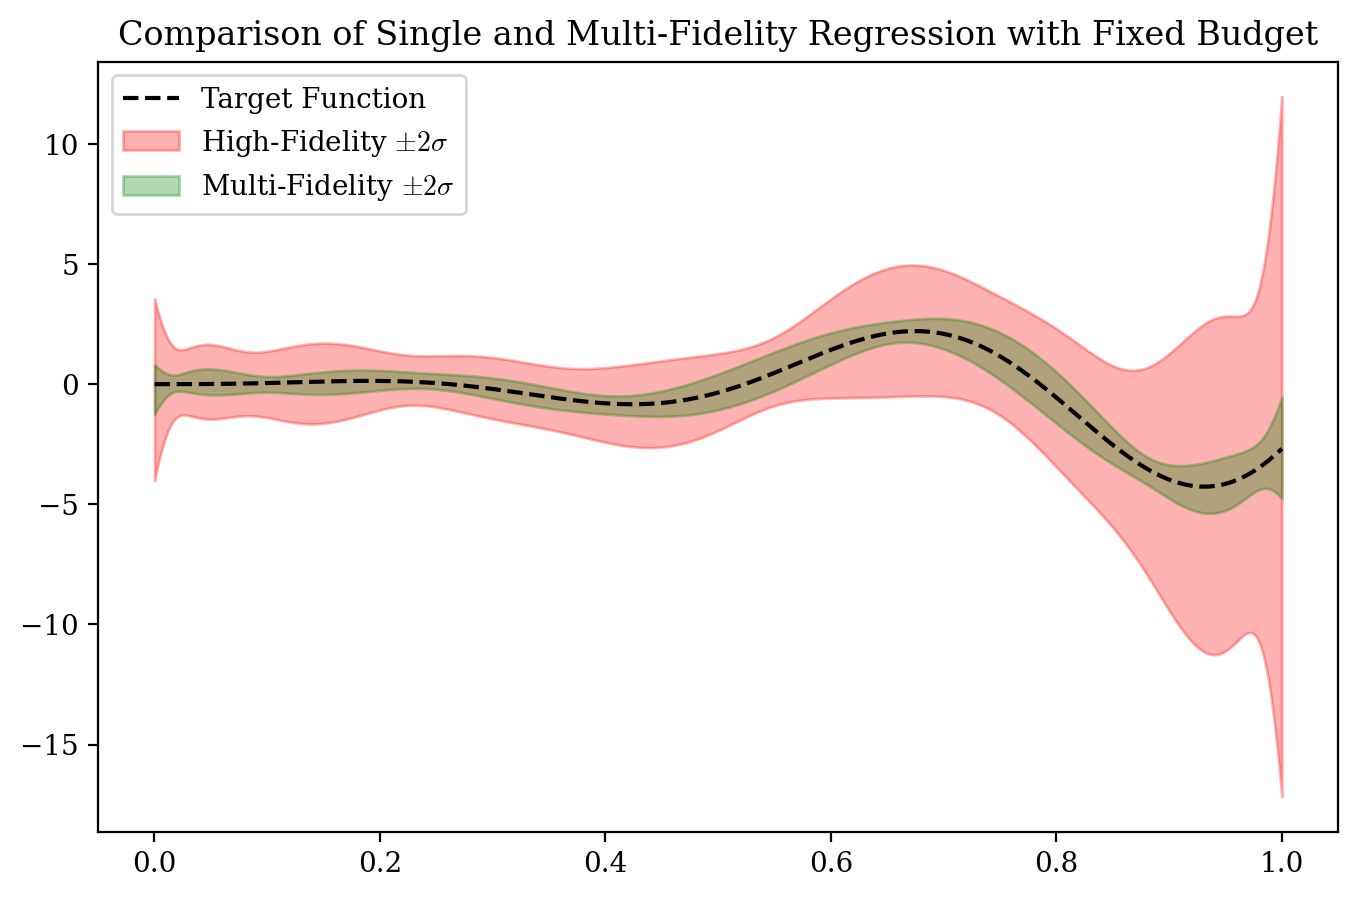

In [42]:
inds = np.argsort(z_pilot)
hf_mean, hf_two_sigma = hf_preds.mean(axis=1), 2*hf_preds.std(axis=1)
mf_mean, mf_two_sigma = mf_preds.mean(axis=1), 2*mf_preds.std(axis=1)
plt.figure(figsize=(8,5), dpi = 200)
plt.plot(z_pilot[inds], y1_pilot[inds], label = "Target Function", linestyle = 'dashed', color = 'black')
plt.fill_between(z_pilot[inds], hf_mean[inds] - hf_two_sigma[inds], hf_mean[inds]+ hf_two_sigma[inds], color = 'red', alpha = 0.3, label = "High-Fidelity $\\pm 2 \\sigma$")
plt.fill_between(z_pilot[inds], mf_mean[inds] - mf_two_sigma[inds], mf_mean[inds]+ mf_two_sigma[inds], color = 'green', alpha = 0.3, label = "Multi-Fidelity $\\pm 2 \\sigma$")
plt.legend()
plt.title("Comparison of Single and Multi-Fidelity Regression with Fixed Budget")

In [21]:
Bs = [25, 50, 100, 200, 400, 800, 1600, 3200, 6400, 12800, 25600]
mf_means = []
mf_two_sigmas = []
hf_means = []
hf_two_sigmas = []


np.random.seed(42)
for B in tqdm(Bs): 
    a = np.trace(Sigma_xx_inv @ Sigma_xy1) 
    b = np.trace(Sigma_xx_inv @ Sigma_xy12 @ np.linalg.lstsq(Sigma_xy2, Sigma_xy12.T)[0])
    n_1 = B * (c1 * (a-b) - np.sqrt(b * c1 * c2 * (a-b))) / (c1 * (c1 *(a-b) - b*c2))
    n_2 = B * (-a * c1 * c2 + (c1 + c2) * np.sqrt(b * c1 * c2 *(a-b))) / (c1*c2*(a*c1 - b*(c1+c2)))
    print("Using %d hf and %d lf samples" % (int(n_1), int(n_2)))
    print("Budget check: %d = " % B, n_1 * c1 + (n_1 + n_2) * c2)

    n_1, n_2 = int(n_1), int(n_2)
    # Setting the minimum condition number
    rcond = 1e-13
    # Setting number of trials 
    n_trials = 1000
    # Creating vector of Squared errors 
    squared_errors = np.zeros(n_trials)
    mf_preds = np.zeros((n_pilot, n_trials))

    for i in range(n_trials):
        # Setting random seed
        # np.random.seed(i) 
        # Taking a random sample 
        z1 = np.random.uniform(0,1,n_1)
        z2 = np.random.uniform(0,1,n_2)
        # Creating polynomial features 
        X1 = scaler.transform(features.transform(z1.reshape(-1,1)))
        X2 = scaler.transform(features.transform(z2.reshape(-1,1)))
        y1_1 = funcs[0](z1)
        y2_2 = funcs[1](z2) 
        y2_1 = funcs[1](z1)
        # Computing optimal CV coefficient 
        A2 = n_2 / (n_1 + n_2) * Sigma_xx_half_inv @ Sigma_xy12 @ np.linalg.pinv(Sigma_xy2)
        # Computing estimate for q 
        q2_2 = A2 @ (X2.T @ (y2_2 - y2_mean)) / n_2 
        q2_1 = A2 @ (X1.T @ (y2_1 - y2_mean)) / n_1 
        q1_1 = Sigma_xx_half_inv @ (X1.T @ (y1_1 - y1_mean)) / n_1 
        q_hat = q2_2 + q1_1 - q2_1 
        # Solving for weights 
        w = Sigma_xx_half_inv @ q_hat 
        # Making predictions 
        yhat = X_pilot @ w + y1_mean 
        mf_preds[:,i] = yhat
        # Storing the MSE 
        squared_errors[i] = np.mean((yhat - y1_pilot)**2)
    
    # Appending results
    mf_means.append(np.mean(squared_errors))
    mf_two_sigmas.append(2*np.std(squared_errors))

    # Verifying MSE approximation with 100% high-fidelity samples
    n_1 = int(B / c1)
    print("Using %d hf samples" % n_1)

    # Creating vector of Squared errors 
    squared_errors = np.zeros(n_trials)
    hf_preds = np.zeros((n_pilot, n_trials))

    for i in range(n_trials):
        # Setting random seed
        # np.random.seed(i) 
        # Taking a random sample 
        z1 = np.random.uniform(0,1,n_1)
        # Creating polynomial features 
        X1 = scaler.transform(features.transform(z1.reshape(-1,1)))
        y1 = funcs[0](z1) 
        # Performing LSR with these inputs 
        mc_cov_xy = X1.T @ (y1 - y1_mean) / n_1
        # Solving for weights 
        w = Sigma_xx_inv @ mc_cov_xy
        # Making predictions 
        yhat = X_pilot @ w + y1_mean
        hf_preds[:,i] = yhat.ravel()
        # Storing the MSE 
        squared_errors[i] = np.mean((yhat - y1_pilot)**2)
    
    # Appending results
    hf_means.append(np.mean(squared_errors))
    hf_two_sigmas.append(2*np.std(squared_errors))

  0%|          | 0/11 [00:00<?, ?it/s]

Using 1 hf and 166 lf samples
Budget check: 25 =  25.00000000000007
Using 2 hf samples


  9%|▉         | 1/11 [00:00<00:06,  1.49it/s]

Using 3 hf and 333 lf samples
Budget check: 50 =  50.00000000000014
Using 5 hf samples


 18%|█▊        | 2/11 [00:01<00:06,  1.45it/s]

...

 82%|████████▏ | 9/11 [00:14<00:05,  2.71s/it]

Using 849 hf and 85343 lf samples
Budget check: 12800 =  12800.000000000036
Using 1280 hf samples


 91%|█████████ | 10/11 [00:28<00:06,  6.26s/it]

Using 1698 hf and 170686 lf samples
Budget check: 25600 =  25600.000000000073
Using 2560 hf samples


100%|██████████| 11/11 [00:56<00:00,  5.14s/it]


/tmp/ipykernel_12086/876282191.py:14: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 25)


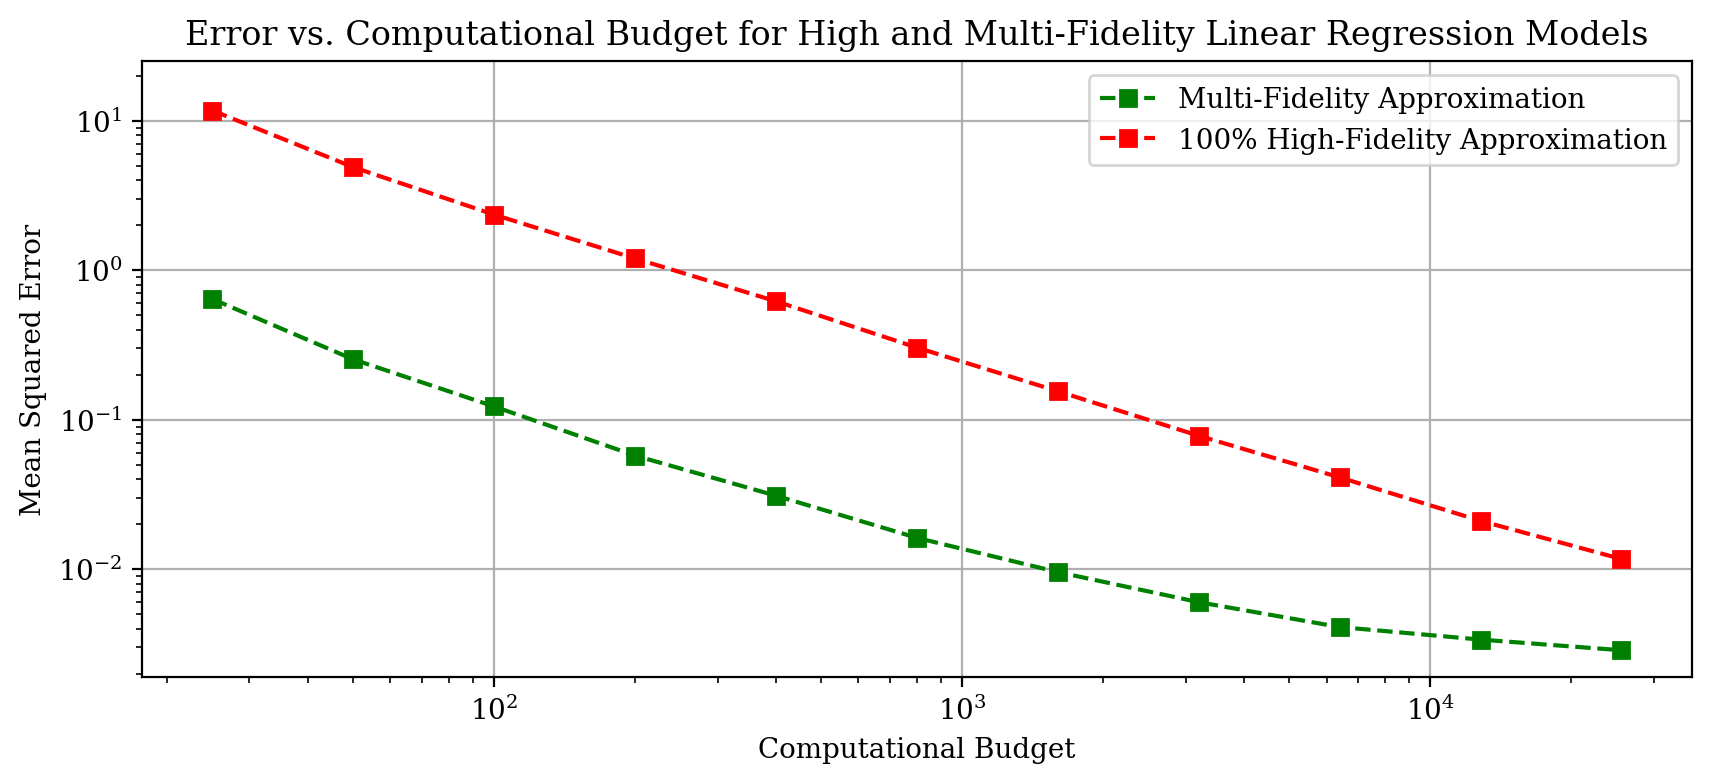

In [27]:
mf_means, mf_two_sigmas = np.array(mf_means), np.array(mf_two_sigmas)
hf_means, hf_two_sigmas = np.array(hf_means), np.array(hf_two_sigmas)

plt.figure(figsize=(10,4), dpi=200)
plt.loglog(Bs, mf_means, color = 'green', label = "Multi-Fidelity Approximation", marker = 's', linestyle = 'dashed')
# plt.fill_between(Bs, mf_means - mf_two_sigmas/2, mf_means + mf_two_sigmas/2, color = 'green', alpha = 0.3)

plt.loglog(Bs, hf_means, color = 'red', label = "100% High-Fidelity Approximation", marker = 's', linestyle = 'dashed')
# plt.fill_between(Bs, hf_means - hf_two_sigmas/2, hf_means + hf_two_sigmas/2, color = 'red', alpha = 0.3)

plt.xlabel("Computational Budget")
plt.ylabel("Mean Squared Error")
plt.title("Error vs. Computational Budget for High and Multi-Fidelity Linear Regression Models")
plt.ylim(0, 25)
plt.legend()
plt.grid()

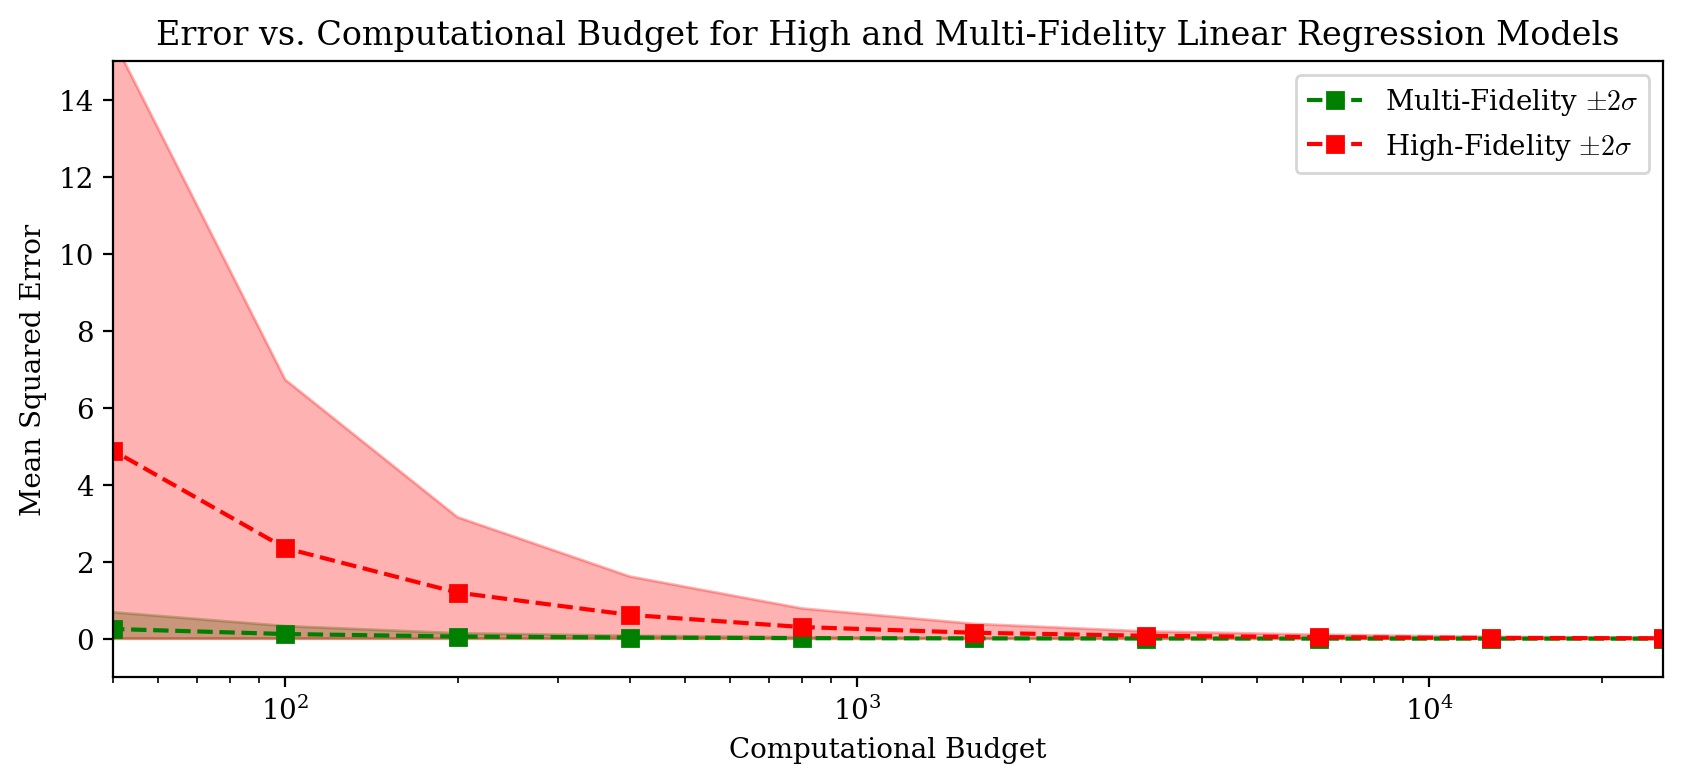

In [45]:
plt.figure(figsize=(10,4), dpi=200)
plt.semilogx(Bs, mf_means, color = 'green', label = "Multi-Fidelity $\\pm 2 \\sigma$", marker = 's', linestyle = 'dashed')
plt.fill_between(Bs, np.maximum(0, mf_means - mf_two_sigmas), mf_means + mf_two_sigmas, color = 'green', alpha = 0.3)

plt.semilogx(Bs, hf_means, color = 'red', label = "High-Fidelity $\\pm 2 \\sigma$", marker = 's', linestyle = 'dashed')
plt.fill_between(Bs, np.maximum(0, hf_means - hf_two_sigmas), hf_means + hf_two_sigmas, color = 'red', alpha = 0.3)

plt.xlabel("Computational Budget")
plt.ylabel("Mean Squared Error")
plt.title("Error vs. Computational Budget for High and Multi-Fidelity Linear Regression Models")
plt.ylim(-1, 15)
plt.xlim(50, Bs[-1])
plt.legend()